# 05 · Discrete-time Markov chains

A Markov chain forgets everything but its present state: P(X_{n+1} = j | X_n = i, past) = P_ij. Weather, an
inventory, a queue observed at departures, a web surfer, a board game - all are chains, and a few matrix
computations answer most questions about them. This notebook covers the transition matrix and its powers, the
structure of the state space (communicating classes, recurrence, periodicity), and estimating a chain from
data - on ten years of daily rain records.

**What you will learn**
- build transition matrices and compute n-step probabilities
- classify states into communicating classes, recurrent and transient, with periods
- simulate chains and relate time averages to the stationary law
- estimate a chain from data and test its assumptions

**Before you start:** notebook 00; matrices and linear systems  ·  **Time:** about 75 min

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engstoch import markov as mk, models, datasets
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## Transition matrices and n-step behaviour

In [2]:
w = models.weather()
chain = w["chain"]
print(chain, "\nP =\n", chain.P)
for k in (1, 2, 5, 20):
    print(f"P^{k:<2} =", np.round(chain.n_step(k), 4).tolist())
p0 = np.array([0.0, 1.0])
print("from a wet day, P(wet) after 1, 2, 3, 7 days:", [round(float(chain.distribution(p0, k)[1]), 4) for k in (1, 2, 3, 7)])
print("stationary distribution:", chain.stationary().round(4), "| eigenvalues of P:", np.round(chain.spectral_gap()["eigenvalues"].real, 4))

MarkovChain(2 states: ['dry', 'wet']) 
P =
 [[0.8 0.2]
 [0.6 0.4]]
P^1  = [[0.8, 0.2], [0.6, 0.4]]
P^2  = [[0.76, 0.24], [0.72, 0.28]]
P^5  = [[0.7501, 0.2499], [0.7498, 0.2502]]
P^20 = [[0.75, 0.25], [0.75, 0.25]]
from a wet day, P(wet) after 1, 2, 3, 7 days: [0.4, 0.28, 0.256, 0.25]
stationary distribution: [0.75 0.25] | eigenvalues of P: [1.  0.2]


The rows of Pⁿ converge to the same vector - the chain forgets where it started - geometrically at the rate of
the second eigenvalue, here 1 − a − b = 0.2: the influence of today's weather shrinks fivefold with every day. The limit is the stationary distribution π = πP.

## Structure: classes, recurrence and period

In [3]:
P = np.array([[0.5, 0.5, 0, 0, 0, 0], [0.3, 0.7, 0, 0, 0, 0], [0.2, 0, 0.3, 0.5, 0, 0], [0, 0, 0.4, 0, 0.6, 0], [0, 0, 0, 0, 0, 1], [0, 0, 0, 0, 1, 0]])
c = mk.MarkovChain(P, list("ABCDEF"))
for cl in c.classify()["classes"]:
    print(f"class {cl['states']}: {'recurrent (closed)' if cl['recurrent'] else 'transient'}, period {cl['period']}")
print("\nP^50 rows from C and from E:", np.round(c.n_step(50)[2], 3).tolist(), np.round(c.n_step(50)[4], 3).tolist())
print("P^51 row from E:", np.round(c.n_step(51)[4], 3).tolist(), " <- E and F alternate for ever")
print("Ehrenfest urn, 10 balls:", models.ehrenfest(10)["chain"].classify())

class ['A', 'B']: recurrent (closed), period 1
class ['C', 'D']: transient, period 1
class ['E', 'F']: recurrent (closed), period 2

P^50 rows from C and from E: [0.15, 0.25, 0.0, 0.0, 0.436, 0.164] [0.0, 0.0, 0.0, 0.0, 1.0, 0.0]
P^51 row from E: [0.0, 0.0, 0.0, 0.0, 0.0, 1.0]  <- E and F alternate for ever
Ehrenfest urn, 10 balls: {'classes': [{'states': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'recurrent': True, 'period': 2}], 'irreducible': True, 'aperiodic': False}


The transition graph's strongly connected components are the communicating classes. In a finite chain a class
is recurrent exactly when no probability leaves it; the others are transient and are eventually left for good.
A recurrent class can be periodic: {E, F} alternates, so Pⁿ does not converge, although the long-run fraction
of time in each state does. The Ehrenfest urn - molecules diffusing between two boxes - is irreducible with
period 2, because the count changes parity at every step.

## Simulation and the law of large numbers for chains

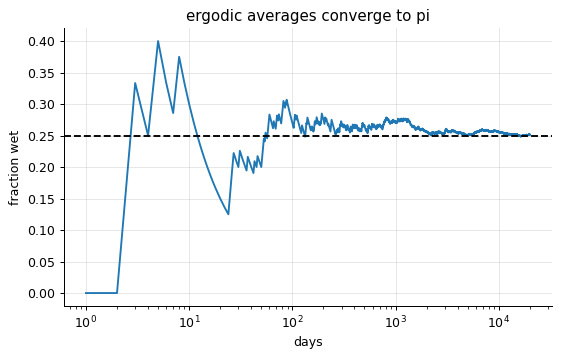

mean wet spell 1.687 days; geometric with parameter P(wet -> dry) = 0.6 gives 1.667


In [4]:
path = chain.simulate(20_000, "dry", R(1))
frac = np.cumsum(path == 1) / np.arange(1, len(path) + 1)
plt.semilogx(np.arange(1, len(path) + 1), frac); plt.axhline(chain.stationary()[1], color="k", ls="--"); plt.xlabel("days"); plt.ylabel("fraction wet"); plt.title("ergodic averages converge to pi"); plt.show()
runs = np.diff(np.flatnonzero(np.diff(np.r_[-1, path, -1]) != 0))
wet_runs = [len(r) for r in np.split(path, np.flatnonzero(np.diff(path)) + 1) if r[0] == 1]
print(f"mean wet spell {np.mean(wet_runs):.3f} days; geometric with parameter P(wet -> dry) = 0.6 gives {1 / 0.6:.3f}")

The fraction of time in each state converges to π (the ergodic theorem for chains). Sojourns in a state are
geometric - a direct consequence of the Markov property, and a testable one: real wet spells are often longer
than geometric, which is evidence of memory beyond one day.

## Estimating a chain from data

In [5]:
wd = pd.read_csv(datasets.path("weather.csv"), comment="#")
x = wd.wet.to_numpy()
est = mk.estimate(x, 2, ["dry", "wet"])
print("MLE of P (ten years):\n", np.round(est["P"], 4), "\nstandard errors:\n", np.round(est["std_error"], 4))
print(f"\nfraction of wet days {x.mean():.4f}; the fitted chain's stationary P(wet) {est['chain'].stationary()[1]:.4f}")
print("first-order vs second-order test:", {k: round(v, 3) for k, v in mk.order_test(x, 2).items()})
season = (wd.day_of_year - 1) // 91
rows = []
for s_, name in enumerate(["Jan-Mar", "Apr-Jun", "Jul-Sep", "Oct-Dec"]):
    idx = np.flatnonzero(season.to_numpy()[:-1] == s_)
    n_dw = np.sum((x[idx] == 0) & (x[idx + 1] == 1)); n_d = np.sum(x[idx] == 0)
    n_wd = np.sum((x[idx] == 1) & (x[idx + 1] == 0)); n_w = np.sum(x[idx] == 1)
    rows.append((name, n_dw / n_d, np.sqrt((n_dw / n_d) * (1 - n_dw / n_d) / n_d), n_wd / n_w))
print(pd.DataFrame(rows, columns=["quarter", "P(dry->wet)", "s.e.", "P(wet->dry)"]).to_string(index=False, float_format="%.3f"))

MLE of P (ten years):
 [[0.8087 0.1913]
 [0.5295 0.4705]] 
standard errors:
 [[0.0076 0.0076]
 [0.0161 0.0161]]

fraction of wet days 0.2652; the fitted chain's stationary P(wet) 0.2654
first-order vs second-order test: {'G2': 10.211, 'df': 2, 'p_value': 0.006}
quarter  P(dry->wet)  s.e.  P(wet->dry)
Jan-Mar        0.275 0.019        0.462
Apr-Jun        0.136 0.013        0.583
Jul-Sep        0.125 0.012        0.638
Oct-Dec        0.260 0.018        0.518


The maximum-likelihood estimate of P_ij is the fraction of departures from i that went to j, with binomial
standard errors. The Anderson-Goodman test rejects the first-order chain (p ≈ 0.006) - but the cause is not a
two-day memory: splitting the data by season shows P(dry → wet) differing between quarters by many standard
errors, and mixing seasons with different persistence mimics higher-order dependence. A homogeneous chain fitted to the whole
record averages over the seasons - it reproduces the annual fraction of wet days and misdescribes every
season. Testing homogeneity is as important as testing the order.

## Inside the algorithm: the period by breadth-first search

In [6]:
P_ = models.ehrenfest(6)["chain"].P
level, queue, g = {0: 0}, [0], 0
while queue:
    i = queue.pop(0)
    for j in np.flatnonzero(P_[i] > 0):
        if j not in level: level[j] = level[i] + 1; queue.append(j)
        else: g = math.gcd(g, level[i] + 1 - level[j])
print("period of the Ehrenfest chain by BFS levels:", g)

period of the Ehrenfest chain by BFS levels: 2


## Exercises
1. A machine is good, worn or broken; write a 3-state chain with a repair policy of your choice, find its stationary law and the long-run fraction of broken days, and check by simulating 10^5 days.
2. Fit a separate two-state chain to each season of `weather.csv`, then simulate ten years from the seasonal model and from the homogeneous model. Compare the distribution of the longest wet spell per year with the data.
3. **Implement it yourself:** write the MLE of P with standard errors from a path of state indices, and check it against `markov.estimate` on the weather data.